In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from recommender import RecommendationEngine
from try_on import run_tryon_pipeline
from size_estimation import BodyMeasurementSystem


In [2]:
# Sample inputs
person_path = "person/p1.jpg"
product_id = 2
csv_path = "csv1.csv"

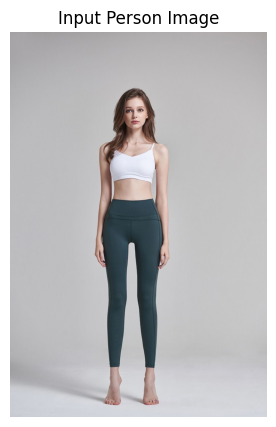

In [3]:
img = cv2.imread(person_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Input Person Image")
plt.axis("off")
plt.show()


In [4]:
output_path = run_tryon_pipeline(
    person_path_input=person_path,
    product_id_input=product_id,
    output_path_input="final_tryon_output.png"
)


Type: TOP
Length: full_length
✅ DONE — try-on completed


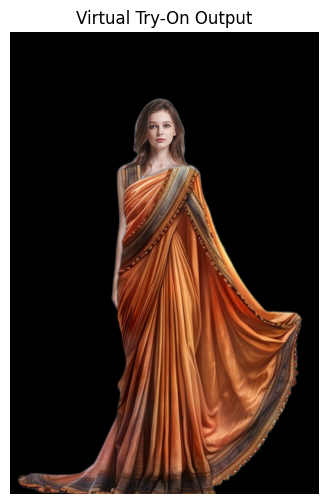

In [5]:
result = cv2.imread(output_path)
result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(result)
plt.title("Virtual Try-On Output")
plt.axis("off")
plt.show()


In [12]:
system = BodyMeasurementSystem()

measurement_result = system.get_measurements_and_size(
    image_path=person_path,
    height_cm=183,
    gender="female"
)

measurement_result


{'shoulder_width': '37.9 cm',
 'torso_length': '55.1 cm',
 'hip_width': '22.3 cm',
 'recommended_size': 'M'}

In [7]:
for key, value in measurement_result.items():
    print(f"{key}: {value}")


shoulder_width: 34.2 cm
torso_length: 49.7 cm
hip_width: 20.1 cm
recommended_size: S


In [8]:
engine = RecommendationEngine(csv_path)

user_profile = {
    "community": "hindu",
    "category": "saree",
    "price_range": (500, 3000)
}


In [9]:
results = engine.recommend(user_profile)
results


,product_id,name,category,community,family,price,rating,image_path,score,explanation
0,1,red_plane_saree,saree,hindu,garnment,2500.0,4.5,img1.png,100,community + category + price match
1,2,orange_traditional_saree,saree,hindu,garnment,2000.0,3.0,img2.jpg,100,community + category + price match
2,3,purple_stylish_saree,saree,hindu,garnment,5000.0,4.0,img3.jpg,85,community + category match
4,5,red_designer_saree,saree,hindu,garnment,6500.0,2.8,img5.png,85,community + category match
32,33,dark_green_lehenga_set,lehenga,hindu,garnment,5000.0,4.9,img33.jpg,70,community match


In [10]:
results[[
    "product_id",
    "name",
    "category",
    "price",
    "rating",
    "explanation"
]]


,product_id,name,category,price,rating,explanation
0,1,red_plane_saree,saree,2500.0,4.5,community + category + price match
1,2,orange_traditional_saree,saree,2000.0,3.0,community + category + price match
2,3,purple_stylish_saree,saree,5000.0,4.0,community + category match
4,5,red_designer_saree,saree,6500.0,2.8,community + category match
32,33,dark_green_lehenga_set,lehenga,5000.0,4.9,community match


In [11]:
top = results.iloc[0]

print("Top Recommended Product:")
print("Name:", top["name"])
print("Price:", top["price"])
print("Rating:", top["rating"])
print("Reason:", top["explanation"])


Top Recommended Product:
Name: red_plane_saree
Price: 2500.0
Rating: 4.5
Reason: community + category + price match


In [ ]:
## ⚠️ Limitations of the System

- Virtual try-on may not work well with extreme poses.
- Loose garments can misalign due to simple scaling logic.
- Pose detection depends on image clarity and lighting.
- Size estimation is approximate and not precise as it uses points extracted from media pipe.
- Recommendation engine is rule-based .

---


In [ ]:
## ✅ Project Summary

This system demonstrates a complete AI-powered fashion platform:

✔ Virtual Try-On using MediaPipe + OpenCV  
✔ Body measurement estimation using pose landmarks  
✔ Community-based recommendation engine  

